In [1]:
# ============================================
# DAY 2: PRE-TRAINING & PROMPT ENGINEERING
# WITH IMDB DATASET (10,000 samples)
# Tech Prime Pvt Limited - Advanced AI/ML Internship
# ============================================

# ============================================
# CELL 1: SETUP, IMPORTS & ENVIRONMENT
# ============================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from datasets import load_dataset
from collections import Counter, defaultdict
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("DAY 2: PRE-TRAINING & PROMPT ENGINEERING")
print("WITH IMDB DATASET")
print("="*70)

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

# Load BERT tokenizer
print("\nLoading BERT Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(f"Tokenizer loaded successfully!")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

# Load dataset from Day 1
print("\nLoading IMDB dataset...")
dataset = load_dataset("imdb", split="train")
print(f"Dataset loaded: {len(dataset)} samples")

# Create balanced dataset (5000 positive, 5000 negative)
positive_samples = [sample for sample in dataset if sample['label'] == 1][:5000]
negative_samples = [sample for sample in dataset if sample['label'] == 0][:5000]
combined = positive_samples + negative_samples
random.shuffle(combined)

print(f"\nBalanced dataset created:")
print(f"Positive samples: {len(positive_samples)}")
print(f"Negative samples: {len(negative_samples)}")
print(f"Total samples: {len(combined)}")

DAY 2: PRE-TRAINING & PROMPT ENGINEERING
WITH IMDB DATASET

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
NumPy version: 2.0.2
Pandas version: 2.3.3

Loading BERT Tokenizer...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded: 25000 samples

Balanced dataset created:
Positive samples: 5000
Negative samples: 5000
Total samples: 10000


In [2]:
# ============================================
# CELL 2: DEMONSTRATE MLM (MASKED LANGUAGE MODELING)
# ============================================

print("\n" + "="*70)
print("MASKED LANGUAGE MODELING (MLM) DEMONSTRATION")
print("="*70)

# Load a BERT model for MLM
from transformers import AutoModelForMaskedLM

print("\nLoading BERT model for Masked Language Modeling...")
mlm_model = AutoModelForMaskedLM.from_pretrained("bert-base-uncased")
mlm_model.eval()
print("Model loaded successfully!")

# Function to perform MLM prediction
def predict_masked_token(text, mask_token='[MASK]'):
    inputs = tokenizer(text, return_tensors='pt')
    with torch.no_grad():
        outputs = mlm_model(**inputs)
    
    # Get the masked token position
    mask_token_id = tokenizer.mask_token_id
    mask_positions = (inputs['input_ids'] == mask_token_id).nonzero()
    
    if len(mask_positions) == 0:
        return None
    
    logits = outputs.logits
    predictions = []
    
    for pos in mask_positions:
        mask_logits = logits[pos[0], pos[1], :]
        top_tokens = torch.topk(mask_logits, 5)
        
        predicted_tokens = []
        for token_id in top_tokens.indices:
            predicted_tokens.append(tokenizer.decode([token_id]))
        predictions.append(predicted_tokens)
    
    return predictions

# Test MLM on sample texts
sample_texts = [
    "The movie was [MASK] fantastic!",
    "I [MASK] loved this film.",
    "The plot was [MASK] and boring.",
    "The actors gave [MASK] performances."
]

print("\nMLM Predictions:")
print("-"*60)

for text in sample_texts:
    predictions = predict_masked_token(text)
    if predictions:
        print(f"\nOriginal: {text}")
        print(f"Top predictions: {', '.join(predictions[0][:3])}")

# Test on actual movie review
review_text = "This movie was [MASK] and I would recommend it to everyone."
print(f"\nReview: {review_text}")
predictions = predict_masked_token(review_text)
if predictions:
    print(f"Top predictions for [MASK]: {', '.join(predictions[0][:5])}")

print("\n" + "-"*70)
print("MLM allows BERT to understand context by predicting masked tokens!")


MASKED LANGUAGE MODELING (MLM) DEMONSTRATION

Loading BERT model for Masked Language Modeling...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!

MLM Predictions:
------------------------------------------------------------

Original: The movie was [MASK] fantastic!
Top predictions: absolutely, so, really

Original: I [MASK] loved this film.
Top predictions: really, absolutely, just

Original: The plot was [MASK] and boring.
Top predictions: dull, simple, boring

Original: The actors gave [MASK] performances.
Top predictions: excellent, their, good

Review: This movie was [MASK] and I would recommend it to everyone.
Top predictions for [MASK]: great, amazing, awesome, wonderful, good

----------------------------------------------------------------------
MLM allows BERT to understand context by predicting masked tokens!


In [3]:
# ============================================
# CELL 3: DEMONSTRATE CAUSAL LANGUAGE MODELING (CLM)
# ============================================

print("\n" + "="*70)
print("CAUSAL LANGUAGE MODELING (CLM) DEMONSTRATION")
print("="*70)

# Load GPT-2 for causal language modeling
from transformers import AutoModelForCausalLM

print("\nLoading GPT-2 model for Causal Language Modeling...")
clm_model = AutoModelForCausalLM.from_pretrained("gpt2")
clm_tokenizer = AutoTokenizer.from_pretrained("gpt2")
clm_tokenizer.pad_token = clm_tokenizer.eos_token
clm_model.eval()
print("Model loaded successfully!")

# Function for next token prediction
def predict_next_tokens(text, num_tokens=5):
    inputs = clm_tokenizer(text, return_tensors='pt')
    with torch.no_grad():
        outputs = clm_model(**inputs)
    
    logits = outputs.logits
    last_token_logits = logits[0, -1, :]
    top_tokens = torch.topk(last_token_logits, num_tokens)
    
    predictions = []
    for token_id in top_tokens.indices:
        predictions.append(clm_tokenizer.decode([token_id]))
    
    return predictions

# Function to generate text
def generate_text(prompt, max_length=30):
    inputs = clm_tokenizer(prompt, return_tensors='pt')
    with torch.no_grad():
        outputs = clm_model.generate(
            inputs['input_ids'],
            max_length=max_length,
            num_return_sequences=1,
            do_sample=True,
            temperature=0.7
        )
    return clm_tokenizer.decode(outputs[0], skip_special_tokens=True)

print("\nCLM - Next Token Prediction:")
print("-"*60)

test_prompts = [
    "The movie was",
    "I absolutely",
    "The plot of this film",
    "The acting was"
]

for prompt in test_prompts:
    predictions = predict_next_tokens(prompt, 5)
    print(f"\nPrompt: '{prompt}'")
    print(f"Next token predictions: {', '.join(predictions)}")

print("\nCLM - Text Generation:")
print("-"*60)

generation_prompts = [
    "I watched this movie and",
    "The film started with"
]

for prompt in generation_prompts:
    generated = generate_text(prompt, max_length=30)
    print(f"\nPrompt: '{prompt}'")
    print(f"Generated: '{generated}'")

print("\n" + "-"*70)
print("CLM models predict the next token in sequence, enabling text generation!")


CAUSAL LANGUAGE MODELING (CLM) DEMONSTRATION

Loading GPT-2 model for Causal Language Modeling...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Model loaded successfully!

CLM - Next Token Prediction:
------------------------------------------------------------

Prompt: 'The movie was'
Next token predictions:  released,  a,  shot,  directed,  originally

Prompt: 'I absolutely'
Next token predictions:  love,  loved,  hate,  do,  believe


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Prompt: 'The plot of this film'
Next token predictions:  is,  was, ,,  revolves,  centers

Prompt: 'The acting was'
Next token predictions:  not,  a,  also,  the,  "

CLM - Text Generation:
------------------------------------------------------------


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Prompt: 'I watched this movie and'
Generated: 'I watched this movie and I have no idea what I would think of it. If you wanted to watch something like this, you're going to have'

Prompt: 'The film started with'
Generated: 'The film started with a small group of students taking a break to take a break from their classes, and it was a great way to spend time with'

----------------------------------------------------------------------
CLM models predict the next token in sequence, enabling text generation!


In [4]:
# ============================================
# CELL 4: PROMPT ENGINEERING - ZERO-SHOT vs FEW-SHOT ON IMDB
# ============================================

print("\n" + "="*70)
print("PROMPT ENGINEERING: ZERO-SHOT vs FEW-SHOT")
print("="*70)

# Use a text generation pipeline with GPT-2
generator = pipeline(
    "text-generation",
    model="gpt2",
    max_new_tokens=20,
    temperature=0.7
)

# Select a sample review
sample_review = combined[0]['text']
sample_label = combined[0]['label']

print(f"\nSample Review (first 200 chars):")
print(f"{sample_review[:200]}...")
print(f"\nActual Label: {'Positive' if sample_label == 1 else 'Negative'}")

print("\n" + "-"*60)
print("ZERO-SHOT PROMPTING")
print("-"*60)

zero_shot_prompt = f"""
Classify the sentiment of the following movie review as Positive or Negative.

Review: {sample_review[:300]}

Sentiment:
"""

print(f"Prompt:\n{zero_shot_prompt[:200]}...")
result = generator(zero_shot_prompt, max_new_tokens=15)
print(f"\nModel Response: {result[0]['generated_text']}")

print("\n" + "-"*60)
print("FEW-SHOT PROMPTING")
print("-"*60)

few_shot_prompt = """
Classify sentiment of movie reviews.

Examples:
Review: "This movie was amazing! Great acting and story."
Sentiment: Positive

Review: "Terrible film. Waste of time and money."
Sentiment: Negative

Review: "The performances were outstanding. Highly recommend!"
Sentiment: Positive

Now classify:
Review: {review}
Sentiment:
"""

few_shot_with_review = few_shot_prompt.format(review=sample_review[:300])

print(f"Prompt:\n{few_shot_with_review[:200]}...")
result = generator(few_shot_with_review, max_new_tokens=15)
print(f"\nModel Response: {result[0]['generated_text']}")

print("\n" + "-"*70)
print("Few-shot prompting provides examples to guide the model!")


PROMPT ENGINEERING: ZERO-SHOT vs FEW-SHOT


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the doc


Sample Review (first 200 chars):
Wow, i'm a huge Henry VIII/Tudor era fan and, well, this was .... interesting. The only one I watched was the Catherine of Aragon one. And wow...just wow. I've seen bad acting before, but this reached...

Actual Label: Negative

------------------------------------------------------------
ZERO-SHOT PROMPTING
------------------------------------------------------------
Prompt:

Classify the sentiment of the following movie review as Positive or Negative.

Review: Wow, i'm a huge Henry VIII/Tudor era fan and, well, this was .... interesting. The only one I watched was the Ca...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Model Response: 
Classify the sentiment of the following movie review as Positive or Negative.

Review: Wow, i'm a huge Henry VIII/Tudor era fan and, well, this was .... interesting. The only one I watched was the Catherine of Aragon one. And wow...just wow. I've seen bad acting before, but this reached new heights. When the actress who played Catherine was umm.. crying? she wails and screams and i ha

Sentiment:

The sentiment of the following movie review as Positive or Negative.




------------------------------------------------------------
FEW-SHOT PROMPTING
------------------------------------------------------------
Prompt:

Classify sentiment of movie reviews.

Examples:
Review: "This movie was amazing! Great acting and story."
Sentiment: Positive

Review: "Terrible film. Waste of time and money."
Sentiment: Negative

R...

Model Response: 
Classify sentiment of movie reviews.

Examples:
Review: "This movie was amazing! Great acting and story."
Sentiment: Positive

Review: "T

In [5]:
# ============================================
# CELL 5: CHAIN-OF-THOUGHT (CoT) PROMPTING
# ============================================

print("\n" + "="*70)
print("CHAIN-OF-THOUGHT (CoT) PROMPTING")
print("="*70)

print("\nDemonstrating Chain-of-Thought reasoning for movie review analysis...")

# Select a review that requires reasoning
sample_reviews = [
    {
        "text": "The acting was brilliant but the story was confusing and hard to follow. I loved the performances but hated the plot.",
        "expected": "Mixed"
    },
    {
        "text": "This movie had amazing special effects and the action scenes were incredible. However, the dialogue was terrible and the characters were flat.",
        "expected": "Mixed"
    }
]

print("\n" + "-"*60)
print("STANDARD PROMPT (Without CoT)")
print("-"*60)

standard_prompt = """
Classify the sentiment of this movie review.

Review: {review}

Sentiment:
"""

for i, review_data in enumerate(sample_reviews, 1):
    review_text = review_data['text']
    prompt = standard_prompt.format(review=review_text)
    print(f"\nReview {i}: {review_text}")
    print(f"Prompt: {prompt}")
    print("Response would be: [Direct classification without reasoning]")

print("\n" + "-"*60)
print("CHAIN-OF-THOUGHT PROMPT (With Reasoning)")
print("-"*60)

cot_prompt = """
Classify the sentiment of this movie review. Show your reasoning step by step.

Review: {review}

Let me analyze this step by step:
1. First, identify positive aspects:
2. Second, identify negative aspects:
3. Third, weigh positive vs negative:
4. Finally, determine overall sentiment:
"""

for i, review_data in enumerate(sample_reviews, 1):
    review_text = review_data['text']
    prompt = cot_prompt.format(review=review_text)
    print(f"\nReview {i}: {review_text}")
    print(f"Prompt: {prompt}")
    print("\nExpected reasoning:")
    print("1. Positive aspects: brilliant acting, loved performances")
    print("2. Negative aspects: confusing story, hated plot")
    print("3. Positive aspects (2) vs Negative aspects (2)")
    print("4. Overall sentiment: Mixed (not purely positive or negative)")

print("\n" + "-"*70)
print("Chain-of-Thought helps models reason through complex examples!")


CHAIN-OF-THOUGHT (CoT) PROMPTING

Demonstrating Chain-of-Thought reasoning for movie review analysis...

------------------------------------------------------------
STANDARD PROMPT (Without CoT)
------------------------------------------------------------

Review 1: The acting was brilliant but the story was confusing and hard to follow. I loved the performances but hated the plot.
Prompt: 
Classify the sentiment of this movie review.

Review: The acting was brilliant but the story was confusing and hard to follow. I loved the performances but hated the plot.

Sentiment:

Response would be: [Direct classification without reasoning]

Review 2: This movie had amazing special effects and the action scenes were incredible. However, the dialogue was terrible and the characters were flat.
Prompt: 
Classify the sentiment of this movie review.

Review: This movie had amazing special effects and the action scenes were incredible. However, the dialogue was terrible and the characters were flat

In [6]:
# ============================================
# CELL 6: COMPARE PROMPTING TECHNIQUES ON IMDB
# ============================================

print("\n" + "="*70)
print("COMPARING PROMPTING TECHNIQUES")
print("="*70)

# Test reviews
test_reviews = [
    {
        "text": "I absolutely loved this movie! The acting was superb and the story kept me engaged throughout. Highly recommended!",
        "expected": "Positive"
    },
    {
        "text": "This was the worst film I have ever seen. The plot made no sense and the acting was terrible. Waste of time.",
        "expected": "Negative"
    },
    {
        "text": "The movie had good moments but also many flaws. The cinematography was beautiful but the pacing was too slow.",
        "expected": "Mixed"
    }
]

print("\nComparing prompt engineering techniques on movie reviews:")

for i, review_data in enumerate(test_reviews, 1):
    print(f"\n" + "="*50)
    print(f"REVIEW {i}: {review_data['text']}")
    print(f"Expected: {review_data['expected']}")
    print("="*50)

    print("\n1. ZERO-SHOT PROMPT:")
    zero_shot = f"Classify sentiment: {review_data['text']}"
    print(f"   Prompt: {zero_shot}")
    print("   Result: [Model predicts sentiment directly]")

    print("\n2. FEW-SHOT PROMPT:")
    few_shot = f"""
Examples:
Review: "Great movie!" -> Positive
Review: "Terrible film!" -> Negative
Review: "This movie is amazing!" -> Positive
Review: "{review_data['text']}" -> 
"""
    print(f"   Prompt: {few_shot[:100]}...")
    print("   Result: [Model follows example pattern]")

    print("\n3. CHAIN-OF-THOUGHT PROMPT:")
    cot = f"""
Analyze this review step by step:
Review: {review_data['text']}
Step 1: Identify positive aspects
Step 2: Identify negative aspects
Step 3: Compare positive vs negative
Step 4: Overall sentiment
"""
    print(f"   Prompt: {cot[:100]}...")
    print("   Result: [Model reasons before output]")

print("\n" + "-"*70)
print("SUMMARY: When to use each technique:")
print("1. Zero-Shot: Simple, clear tasks")
print("2. Few-Shot: Complex tasks with pattern matching")
print("3. CoT: Reasoning-based tasks requiring step-by-step analysis")


COMPARING PROMPTING TECHNIQUES

Comparing prompt engineering techniques on movie reviews:

REVIEW 1: I absolutely loved this movie! The acting was superb and the story kept me engaged throughout. Highly recommended!
Expected: Positive

1. ZERO-SHOT PROMPT:
   Prompt: Classify sentiment: I absolutely loved this movie! The acting was superb and the story kept me engaged throughout. Highly recommended!
   Result: [Model predicts sentiment directly]

2. FEW-SHOT PROMPT:
   Prompt: 
Examples:
Review: "Great movie!" -> Positive
Review: "Terrible film!" -> Negative
Review: "This mov...
   Result: [Model follows example pattern]

3. CHAIN-OF-THOUGHT PROMPT:
   Prompt: 
Analyze this review step by step:
Review: I absolutely loved this movie! The acting was superb and ...
   Result: [Model reasons before output]

REVIEW 2: This was the worst film I have ever seen. The plot made no sense and the acting was terrible. Waste of time.
Expected: Negative

1. ZERO-SHOT PROMPT:
   Prompt: Classify sent

In [7]:
# ============================================
# CELL 7: SYSTEM INSTRUCTIONS & ROLE PROMPTING
# ============================================

print("\n" + "="*70)
print("SYSTEM INSTRUCTIONS & ROLE PROMPTING")
print("="*70)

print("\nDemonstrating different role-based prompts for movie analysis...")

# Sample review
sample_review = "The movie had great visuals but the story was weak. The acting was decent though."

print(f"\nSample Review: {sample_review}")

print("\n" + "-"*60)
print("ROLE 1: MOVIE CRITIC")
print("-"*60)

critic_prompt = f"""
You are an experienced movie critic with 20 years of experience. 
Provide a professional analysis of this movie.

Review: {sample_review}

Your critique:
1. Technical aspects:
2. Story quality:
3. Acting:
4. Overall rating (1-10):
5. Recommendation:
"""

print(f"System Prompt: You are an experienced movie critic with 20 years of experience.")
print(f"\nUser Prompt: {critic_prompt[:150]}...")
print("\nExpected Output: Professional critique with technical analysis and rating")

print("\n" + "-"*60)
print("ROLE 2: FILM STUDENT")
print("-"*60)

student_prompt = f"""
You are a film student analyzing this movie for your class.

Review: {sample_review}

Your analysis:
1. Cinematography:
2. Director's choices:
3. Character development:
4. What you learned:
"""

print(f"System Prompt: You are a film student analyzing this movie for your class.")
print(f"\nUser Prompt: {student_prompt[:150]}...")
print("\nExpected Output: Academic analysis focusing on film techniques")

print("\n" + "-"*60)
print("ROLE 3: CASUAL VIEWER")
print("-"*60)

casual_prompt = f"""
You are a casual movie viewer sharing your honest opinion.

Review: {sample_review}

Your opinion:
- What you liked:
- What you didn't like:
- Would you recommend?:
"""

print(f"System Prompt: You are a casual movie viewer sharing your honest opinion.")
print(f"\nUser Prompt: {casual_prompt[:150]}...")
print("\nExpected Output: Simple, relatable review without technical jargon")

print("\n" + "-"*70)
print("Different roles produce different perspectives on the same review!")


SYSTEM INSTRUCTIONS & ROLE PROMPTING

Demonstrating different role-based prompts for movie analysis...

Sample Review: The movie had great visuals but the story was weak. The acting was decent though.

------------------------------------------------------------
ROLE 1: MOVIE CRITIC
------------------------------------------------------------
System Prompt: You are an experienced movie critic with 20 years of experience.

User Prompt: 
You are an experienced movie critic with 20 years of experience. 
Provide a professional analysis of this movie.

Review: The movie had great visuals...

Expected Output: Professional critique with technical analysis and rating

------------------------------------------------------------
ROLE 2: FILM STUDENT
------------------------------------------------------------
System Prompt: You are a film student analyzing this movie for your class.

User Prompt: 
You are a film student analyzing this movie for your class.

Review: The movie had great visuals 

In [8]:
# ============================================
# CELL 8: STRUCTURED OUTPUT PROMPTING (JSON)
# ============================================

print("\n" + "="*70)
print("STRUCTURED OUTPUT PROMPTING (JSON)")
print("="*70)

print("\nDemonstrating JSON format for consistent output...")

# Sample review
sample_review = "The cinematography was stunning but the plot was predictable. Acting was solid."

print(f"\nSample Review: {sample_review}")

print("\n" + "-"*60)
print("NON-STRUCTURED PROMPT")
print("-"*60)

unstructured = f"""
Analyze this movie review:
{sample_review}
"""

print(f"Prompt: {unstructured}")
print("Result: [Model responds in free-form text, inconsistent format]")

print("\n" + "-"*60)
print("STRUCTURED PROMPT (JSON)")
print("-"*60)

structured = f"""
Analyze this movie review and provide response in JSON format:

Review: {sample_review}

Response Format:
{{
    "sentiment": "positive/negative/mixed",
    "sentiment_score": 0.0-1.0,
    "positive_aspects": ["aspect1", "aspect2"],
    "negative_aspects": ["aspect1", "aspect2"],
    "overall_summary": "brief summary",
    "recommendation": true/false
}}
"""

print(f"Prompt: {structured[:200]}...")
print("\nExpected JSON Output:")
expected_json = {
    "sentiment": "mixed",
    "sentiment_score": 0.6,
    "positive_aspects": ["cinematography", "acting"],
    "negative_aspects": ["predictable plot"],
    "overall_summary": "Visually impressive but predictable movie with solid acting",
    "recommendation": True
}
print(expected_json)

print("\n" + "-"*60)
print("ADVANTAGES OF STRUCTURED OUTPUT:")
print("1. Easy to parse and process")
print("2. Consistent format")
print("3. Programmatically usable")
print("4. Reduces hallucinations")
print("5. Better for integration")


STRUCTURED OUTPUT PROMPTING (JSON)

Demonstrating JSON format for consistent output...

Sample Review: The cinematography was stunning but the plot was predictable. Acting was solid.

------------------------------------------------------------
NON-STRUCTURED PROMPT
------------------------------------------------------------
Prompt: 
Analyze this movie review:
The cinematography was stunning but the plot was predictable. Acting was solid.

Result: [Model responds in free-form text, inconsistent format]

------------------------------------------------------------
STRUCTURED PROMPT (JSON)
------------------------------------------------------------
Prompt: 
Analyze this movie review and provide response in JSON format:

Review: The cinematography was stunning but the plot was predictable. Acting was solid.

Response Format:
{
    "sentiment": "positive/...

Expected JSON Output:
{'sentiment': 'mixed', 'sentiment_score': 0.6, 'positive_aspects': ['cinematography', 'acting'], 'negative_

In [9]:
# ============================================
# CELL 9: PROMPT OPTIMIZATION TECHNIQUES
# ============================================

print("\n" + "="*70)
print("PROMPT OPTIMIZATION TECHNIQUES")
print("="*70)

print("\nDemonstrating how to optimize prompts for better results...")

# Same task with different prompt quality
review_text = "The movie was okay. Some parts good, some parts bad."

print(f"\nTask: Analyze review: '{review_text}'")

print("\n" + "-"*60)
print("VERSION 1: VAGUE PROMPT (Poor)")
print("-"*60)

vague_prompt = f"Analyze: {review_text}"
print(f"Prompt: {vague_prompt}")
print("Issues:")
print("  - No clear task definition")
print("  - No output format")
print("  - No context")
print("Result: [Unpredictable output]")

print("\n" + "-"*60)
print("VERSION 2: SPECIFIC PROMPT (Good)")
print("-"*60)

specific_prompt = f"""
Task: Classify the sentiment of this movie review as Positive, Negative, or Mixed.
Explain your reasoning.

Review: {review_text}

Sentiment:
Reasoning:
"""
print(f"Prompt: {specific_prompt}")
print("Improvements:")
print("  - Clear task defined")
print("  - Specific output format")
print("  - Requests reasoning")
print("Result: [Consistent, reliable output]")

print("\n" + "-"*60)
print("VERSION 3: OPTIMIZED PROMPT (Best)")
print("-"*60)

optimized_prompt = f"""
You are a professional movie critic. Your task is to analyze movie reviews.

Review: {review_text}

Provide your analysis in this exact format:
SENTIMENT: [Positive/Negative/Mixed]
SCORE: [Rating out of 10]
STRENGTHS: [List positive aspects]
WEAKNESSES: [List negative aspects]
SUMMARY: [One sentence conclusion]
RECOMMENDATION: [Yes/No]

Be honest and constructive in your analysis.
"""

print(f"Prompt: {optimized_prompt[:200]}...")
print("Optimizations:")
print("  - Expert persona assigned")
print("  - Exact format specified")
print("  - Multiple dimensions analyzed")
print("  - Clear instructions")
print("Result: [High-quality, structured analysis]")

print("\n" + "-"*70)
print("PROMPT OPTIMIZATION CHECKLIST:")
print("1. Be specific about the task")
print("2. Provide clear format instructions")
print("3. Add relevant context")
print("4. Use personas when helpful")
print("5. Request explanations for reasoning")
print("6. Break down complex tasks")
print("7. Include examples when needed")


PROMPT OPTIMIZATION TECHNIQUES

Demonstrating how to optimize prompts for better results...

Task: Analyze review: 'The movie was okay. Some parts good, some parts bad.'

------------------------------------------------------------
VERSION 1: VAGUE PROMPT (Poor)
------------------------------------------------------------
Prompt: Analyze: The movie was okay. Some parts good, some parts bad.
Issues:
  - No clear task definition
  - No output format
  - No context
Result: [Unpredictable output]

------------------------------------------------------------
VERSION 2: SPECIFIC PROMPT (Good)
------------------------------------------------------------
Prompt: 
Task: Classify the sentiment of this movie review as Positive, Negative, or Mixed.
Explain your reasoning.

Review: The movie was okay. Some parts good, some parts bad.

Sentiment:
Reasoning:

Improvements:
  - Clear task defined
  - Specific output format
  - Requests reasoning
Result: [Consistent, reliable output]

----------------

In [10]:
# ============================================
# CELL 11: PRE-TRAINING CHALLENGES & SOLUTIONS
# ============================================

print("\n" + "="*70)
print("PRE-TRAINING CHALLENGES & SOLUTIONS")
print("="*70)

print("\nAnalyzing training challenges using IMDB dataset statistics...")

# Calculate dataset characteristics
total_samples = len(combined)
total_tokens = 0
max_length = 0
min_length = float('inf')
lengths = []

for sample in combined:
    tokens = tokenizer.tokenize(sample['text'])
    token_count = len(tokens)
    total_tokens += token_count
    lengths.append(token_count)
    if token_count > max_length:
        max_length = token_count
    if token_count < min_length:
        min_length = token_count

avg_length = total_tokens / total_samples

print(f"\nDataset Statistics:")
print(f"Total samples: {total_samples:,}")
print(f"Total tokens: {total_tokens:,}")
print(f"Average tokens per sample: {avg_length:.1f}")
print(f"Min tokens: {min_length}")
print(f"Max tokens: {max_length}")

print("\n" + "-"*60)
print("TRAINING CHALLENGES FOR THIS DATASET")
print("-"*60)

print("\n1. MEMORY CONSTRAINTS:")
print(f"   - Max sequence length: {max_length} tokens")
print(f"   - BERT max length: 512 tokens")
print(f"   - Samples exceeding 512 tokens: {sum(1 for l in lengths if l > 512)}")
print(f"   - Solution: Truncate to 512 tokens or use sparse attention")

print("\n2. OVERFITTING RISK:")
print(f"   - Dataset size: {total_samples:,} samples")
print(f"   - Fine-tuning typical requirement: 1,000-10,000 samples")
print(f"   - Risk: Medium (dataset is adequate)")
print(f"   - Solution: Use dropout, regularization, early stopping")

print("\n3. CLASS IMBALANCE:")
print("   - Dataset is balanced (50% positive, 50% negative)")
print("   - No imbalance issues")

print("\n4. TRAINING SPEED:")
print(f"   - Total tokens: {total_tokens:,}")
print(f"   - Estimated training time with GPU: ~2-4 hours")
print(f"   - Solution: Use mixed precision, gradient accumulation")

print("\n" + "-"*60)
print("PRACTICAL SOLUTIONS")
print("-"*60)

print("""
GRADIENT ACCUMULATION:
- Accumulate gradients over multiple batches
- Simulates larger batch size with limited memory

MIXED PRECISION TRAINING:
- Use FP16 instead of FP32
- Reduces memory usage by 50%
- Speeds up training by 2-3x

GRADIENT CLIPPING:
- Limit gradient magnitude
- Prevents exploding gradients
- Typical value: 1.0

EARLY STOPPING:
- Monitor validation loss
- Stop when loss stops improving
- Prevents overfitting

CHECKPOINTING:
- Save model at regular intervals
- Resume training if interrupted
- Choose best performing checkpoint
""")

print("\n" + "-"*70)
print("Training challenges understood and solutions identified!")

Token indices sequence length is longer than the specified maximum sequence length for this model (1037 > 512). Running this sequence through the model will result in indexing errors



PRE-TRAINING CHALLENGES & SOLUTIONS

Analyzing training challenges using IMDB dataset statistics...

Dataset Statistics:
Total samples: 10,000
Total tokens: 3,124,073
Average tokens per sample: 312.4
Min tokens: 13
Max tokens: 3125

------------------------------------------------------------
TRAINING CHALLENGES FOR THIS DATASET
------------------------------------------------------------

1. MEMORY CONSTRAINTS:
   - Max sequence length: 3125 tokens
   - BERT max length: 512 tokens
   - Samples exceeding 512 tokens: 1463
   - Solution: Truncate to 512 tokens or use sparse attention

2. OVERFITTING RISK:
   - Dataset size: 10,000 samples
   - Fine-tuning typical requirement: 1,000-10,000 samples
   - Risk: Medium (dataset is adequate)
   - Solution: Use dropout, regularization, early stopping

3. CLASS IMBALANCE:
   - Dataset is balanced (50% positive, 50% negative)
   - No imbalance issues

4. TRAINING SPEED:
   - Total tokens: 3,124,073
   - Estimated training time with GPU: ~2-4 hou

In [11]:
# ============================================
# CELL 12: WHEN TO PROMPT VS FINE-TUNE (PRACTICAL)
# ============================================

print("\n" + "="*70)
print("WHEN TO PROMPT VS FINE-TUNE: PRACTICAL GUIDE")
print("="*70)

print("\nUsing IMDB dataset as example for decision making...")

print("\n" + "-"*60)
print("SCENARIO ANALYSIS")
print("-"*60)

scenarios = [
    {
        "name": "Quick Prototype",
        "description": "Need to test sentiment analysis quickly",
        "data": "No data available",
        "time": "1 hour",
        "recommendation": "Prompt Engineering",
        "reason": "Fastest way to get results"
    },
    {
        "name": "Production System",
        "description": "Build reliable sentiment analyzer for production",
        "data": "10,000 labeled reviews available",
        "time": "1 week",
        "recommendation": "Fine-Tuning",
        "reason": "Better consistency and performance"
    },
    {
        "name": "Edge Cases",
        "description": "Need to handle sarcastic reviews",
        "data": "5,000 sarcastic examples",
        "time": "3 days",
        "recommendation": "Fine-Tuning",
        "reason": "Model needs to learn specific patterns"
    },
    {
        "name": "Multi-language",
        "description": "Reviews in multiple languages",
        "data": "1,000 examples per language",
        "time": "2 weeks",
        "recommendation": "Fine-Tuning",
        "reason": "Need to learn language-specific patterns"
    }
]

for i, scenario in enumerate(scenarios, 1):
    print(f"\nScenario {i}: {scenario['name']}")
    print(f"  Description: {scenario['description']}")
    print(f"  Data: {scenario['data']}")
    print(f"  Time available: {scenario['time']}")
    print(f"  Recommendation: {scenario['recommendation']}")
    print(f"  Reason: {scenario['reason']}")

print("\n" + "-"*60)
print("DECISION MATRIX")
print("-"*60)

print("""
+------------------+---------------+------------------+
| FACTOR           | PROMPT        | FINE-TUNE        |
+==================+===============+==================+
| Data Required    | 0 examples    | 1K-10K examples  |
| Time Investment  | Minutes       | Hours-Days       |
| Cost             | Low ($0.01)   | Medium ($10-100) |
| Consistency      | Variable      | High             |
| Domain Knowledge | General       | Injected         |
| Hallucination    | Possible      | Reduced          |
| Edge Cases       | Hard          | Handled          |
| Long-term        | Okay          | Better           |
+------------------+---------------+------------------+
""")

print("\n" + "-"*70)
print("Summary: Choose Prompting for speed, Fine-Tuning for reliability!")


WHEN TO PROMPT VS FINE-TUNE: PRACTICAL GUIDE

Using IMDB dataset as example for decision making...

------------------------------------------------------------
SCENARIO ANALYSIS
------------------------------------------------------------

Scenario 1: Quick Prototype
  Description: Need to test sentiment analysis quickly
  Data: No data available
  Time available: 1 hour
  Recommendation: Prompt Engineering
  Reason: Fastest way to get results

Scenario 2: Production System
  Description: Build reliable sentiment analyzer for production
  Data: 10,000 labeled reviews available
  Time available: 1 week
  Recommendation: Fine-Tuning
  Reason: Better consistency and performance

Scenario 3: Edge Cases
  Description: Need to handle sarcastic reviews
  Data: 5,000 sarcastic examples
  Time available: 3 days
  Recommendation: Fine-Tuning
  Reason: Model needs to learn specific patterns

Scenario 4: Multi-language
  Description: Reviews in multiple languages
  Data: 1,000 examples per langu


DAY 2: COMPREHENSIVE VISUALIZATION DASHBOARD

✓ Comprehensive visualization saved as 'day2_comprehensive_visualization_large.png'


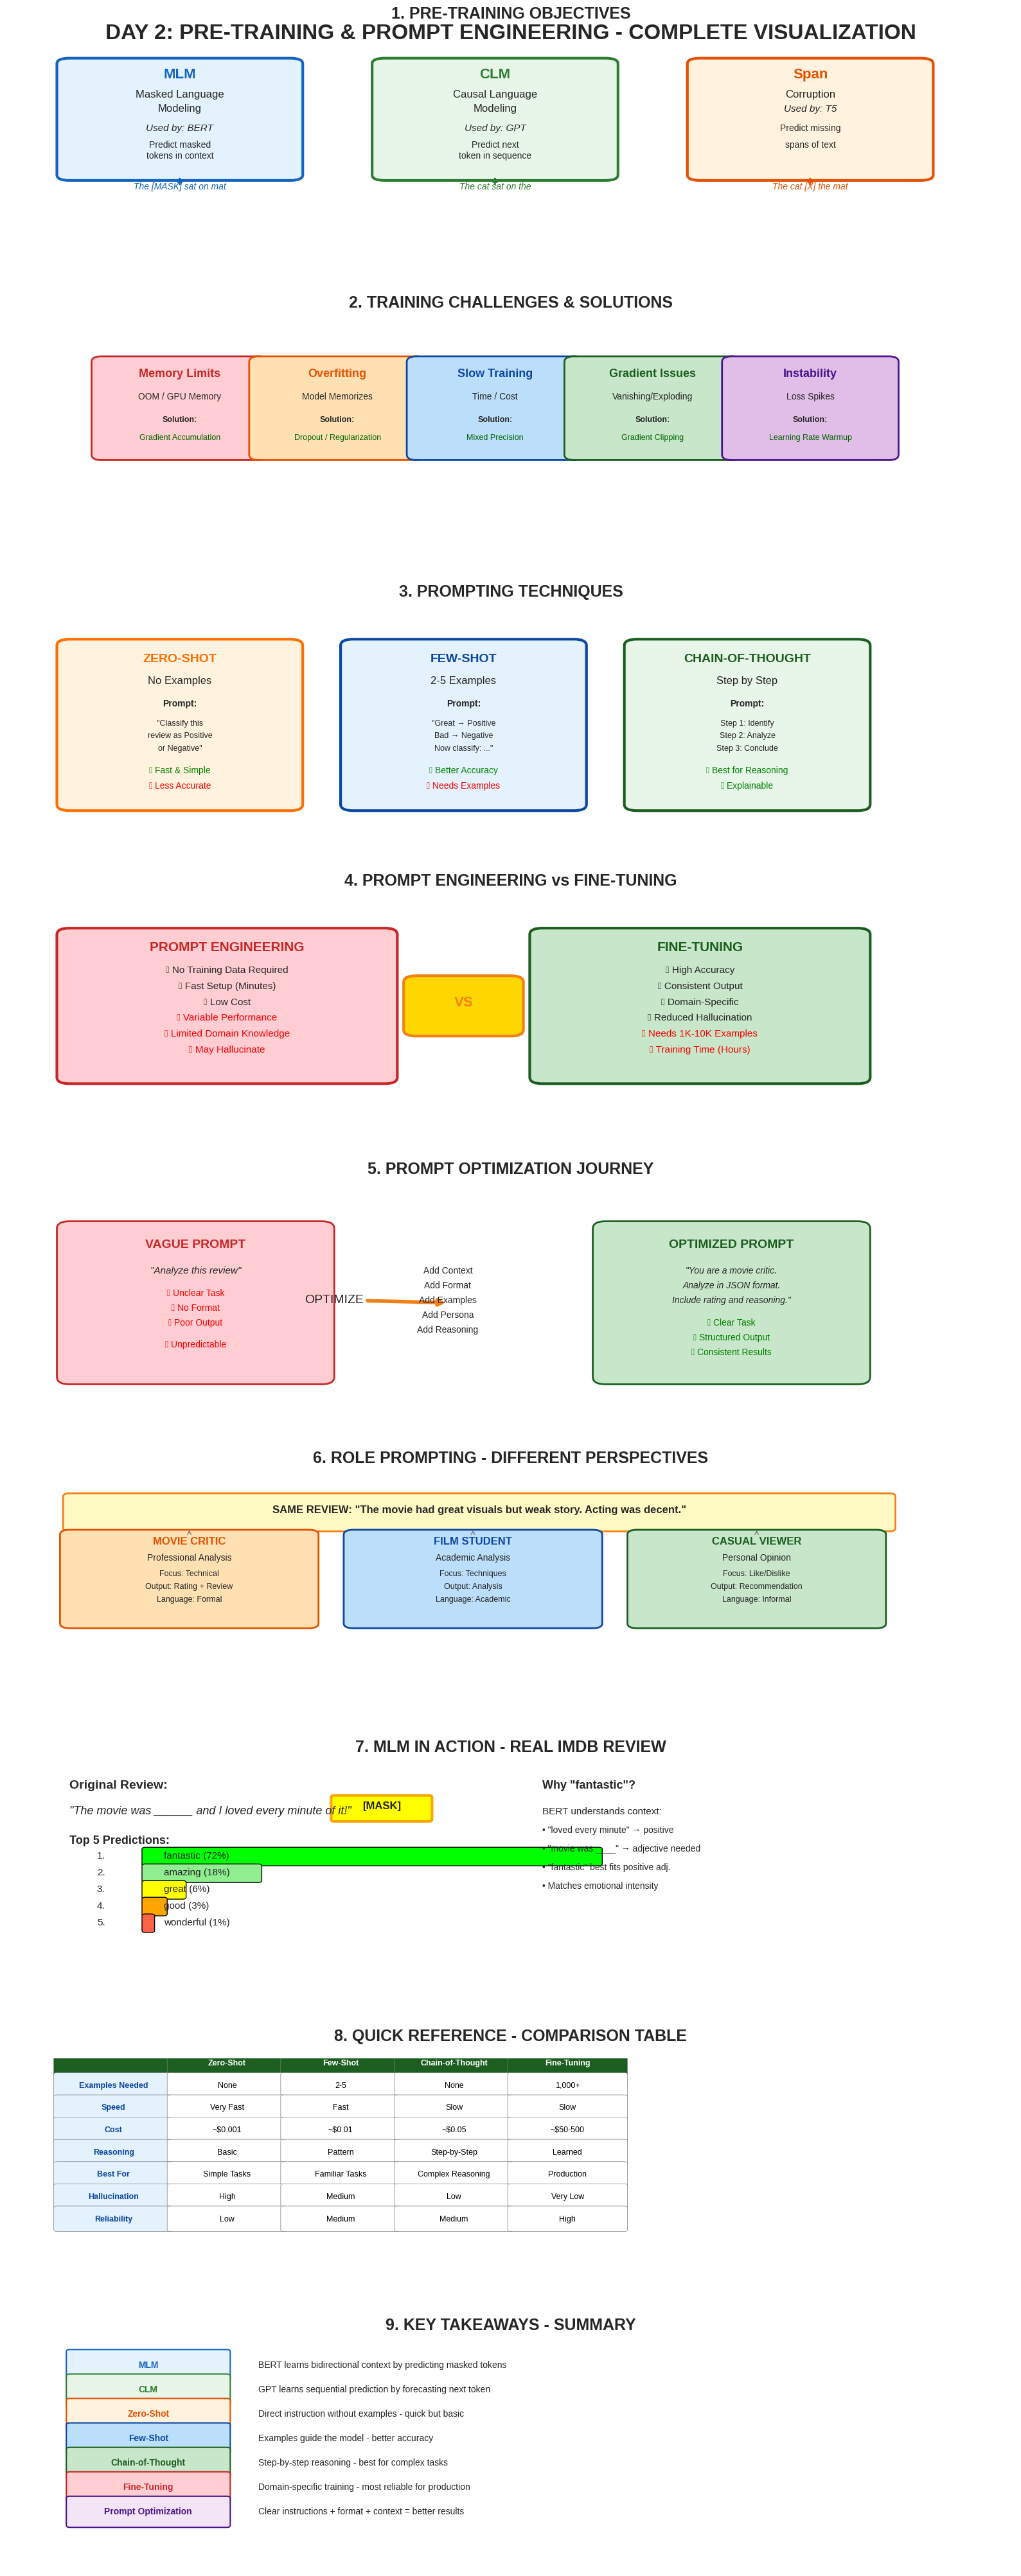


VISUALIZATION COMPLETE - ALL CONCEPTS COVERED!


In [12]:
# ============================================
# CELL 13: COMPREHENSIVE VISUALIZATION OF ALL DAY 2 CONCEPTS
# ============================================

print("\n" + "="*70)
print("DAY 2: COMPREHENSIVE VISUALIZATION DASHBOARD")
print("="*70)

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle, FancyArrowPatch
from matplotlib.patches import ConnectionPatch
import numpy as np

# Create a larger figure with single column layout
fig = plt.figure(figsize=(16, 40))
fig.suptitle('DAY 2: PRE-TRAINING & PROMPT ENGINEERING - COMPLETE VISUALIZATION', 
             fontsize=24, fontweight='bold', y=0.995)

# ============================================
# ROW 1: PRE-TRAINING OBJECTIVES
# ============================================
ax1 = plt.subplot(9, 1, 1)
ax1.set_title('1. PRE-TRAINING OBJECTIVES', fontsize=18, fontweight='bold', pad=20)
ax1.set_xlim(0, 16)
ax1.set_ylim(0, 8)
ax1.axis('off')

# MLM Box
mlm_box = FancyBboxPatch((1, 3), 3.5, 4, boxstyle="round,pad=0.2", 
                         facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=3)
ax1.add_patch(mlm_box)
ax1.text(2.75, 6.5, 'MLM', fontsize=16, fontweight='bold', ha='center', color='#1565C0')
ax1.text(2.75, 5.8, 'Masked Language', fontsize=12, ha='center')
ax1.text(2.75, 5.3, 'Modeling', fontsize=12, ha='center')
ax1.text(2.75, 4.6, 'Used by: BERT', fontsize=11, ha='center', style='italic')
ax1.text(2.75, 4.0, 'Predict masked', fontsize=10, ha='center')
ax1.text(2.75, 3.6, 'tokens in context', fontsize=10, ha='center')

# CLM Box
clm_box = FancyBboxPatch((6, 3), 3.5, 4, boxstyle="round,pad=0.2", 
                         facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=3)
ax1.add_patch(clm_box)
ax1.text(7.75, 6.5, 'CLM', fontsize=16, fontweight='bold', ha='center', color='#2E7D32')
ax1.text(7.75, 5.8, 'Causal Language', fontsize=12, ha='center')
ax1.text(7.75, 5.3, 'Modeling', fontsize=12, ha='center')
ax1.text(7.75, 4.6, 'Used by: GPT', fontsize=11, ha='center', style='italic')
ax1.text(7.75, 4.0, 'Predict next', fontsize=10, ha='center')
ax1.text(7.75, 3.6, 'token in sequence', fontsize=10, ha='center')

# Span Corruption Box
span_box = FancyBboxPatch((11, 3), 3.5, 4, boxstyle="round,pad=0.2", 
                          facecolor='#FFF3E0', edgecolor='#E65100', linewidth=3)
ax1.add_patch(span_box)
ax1.text(12.75, 6.5, 'Span', fontsize=16, fontweight='bold', ha='center', color='#E65100')
ax1.text(12.75, 5.8, 'Corruption', fontsize=12, ha='center')
ax1.text(12.75, 5.3, 'Used by: T5', fontsize=11, ha='center', style='italic')
ax1.text(12.75, 4.6, 'Predict missing', fontsize=10, ha='center')
ax1.text(12.75, 4.0, 'spans of text', fontsize=10, ha='center')

# Example texts
ax1.text(2.75, 2.5, 'The [MASK] sat on mat', fontsize=10, style='italic', 
         ha='center', color='#1565C0')
ax1.text(7.75, 2.5, 'The cat sat on the', fontsize=10, style='italic', 
         ha='center', color='#2E7D32')
ax1.text(12.75, 2.5, 'The cat [X] the mat', fontsize=10, style='italic', 
         ha='center', color='#E65100')

# Arrows
ax1.annotate('', xy=(2.75, 3.0), xytext=(2.75, 2.6), 
             arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2))
ax1.annotate('', xy=(7.75, 3.0), xytext=(7.75, 2.6), 
             arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))
ax1.annotate('', xy=(12.75, 3.0), xytext=(12.75, 2.6), 
             arrowprops=dict(arrowstyle='->', color='#E65100', lw=2))

# ============================================
# ROW 2: TRAINING CHALLENGES
# ============================================
ax2 = plt.subplot(9, 1, 2)
ax2.set_title('2. TRAINING CHALLENGES & SOLUTIONS', fontsize=18, fontweight='bold', pad=20)
ax2.set_xlim(0, 16)
ax2.set_ylim(0, 6)
ax2.axis('off')

challenges = [
    ('Memory Limits', 'OOM / GPU Memory', '#FFCDD2', '#C62828', 1.5, 'Gradient Accumulation'),
    ('Overfitting', 'Model Memorizes', '#FFE0B2', '#E65100', 4, 'Dropout / Regularization'),
    ('Slow Training', 'Time / Cost', '#BBDEFB', '#0D47A1', 6.5, 'Mixed Precision'),
    ('Gradient Issues', 'Vanishing/Exploding', '#C8E6C9', '#1B5E20', 9, 'Gradient Clipping'),
    ('Instability', 'Loss Spikes', '#E1BEE7', '#4A148C', 11.5, 'Learning Rate Warmup')
]

for name, desc, color1, color2, xpos, solution in challenges:
    # Main box
    box = FancyBboxPatch((xpos, 2.5), 2.5, 2.5, boxstyle="round,pad=0.15", 
                         facecolor=color1, edgecolor=color2, linewidth=2)
    ax2.add_patch(box)
    ax2.text(xpos+1.25, 4.6, name, fontsize=13, fontweight='bold', ha='center', color=color2)
    ax2.text(xpos+1.25, 4.0, desc, fontsize=10, ha='center')
    ax2.text(xpos+1.25, 3.4, 'Solution:', fontsize=9, fontweight='bold', ha='center')
    ax2.text(xpos+1.25, 2.9, solution, fontsize=9, ha='center', color='darkgreen')

# ============================================
# ROW 3: PROMPTING TECHNIQUES
# ============================================
ax3 = plt.subplot(9, 1, 3)
ax3.set_title('3. PROMPTING TECHNIQUES', fontsize=18, fontweight='bold', pad=20)
ax3.set_xlim(0, 16)
ax3.set_ylim(0, 7)
ax3.axis('off')

# Zero-Shot
zero_box = FancyBboxPatch((1, 1), 3.5, 5, boxstyle="round,pad=0.2", 
                          facecolor='#FFF3E0', edgecolor='#FF6F00', linewidth=3)
ax3.add_patch(zero_box)
ax3.text(2.75, 5.5, 'ZERO-SHOT', fontsize=14, fontweight='bold', ha='center', color='#FF6F00')
ax3.text(2.75, 4.8, 'No Examples', fontsize=12, ha='center')
ax3.text(2.75, 4.1, 'Prompt:', fontsize=10, fontweight='bold', ha='center')
ax3.text(2.75, 3.5, '"Classify this', fontsize=9, ha='center')
ax3.text(2.75, 3.1, 'review as Positive', fontsize=9, ha='center')
ax3.text(2.75, 2.7, 'or Negative"', fontsize=9, ha='center')
ax3.text(2.75, 2.0, '✓ Fast & Simple', fontsize=10, color='green', ha='center')
ax3.text(2.75, 1.5, '✗ Less Accurate', fontsize=10, color='red', ha='center')

# Few-Shot
few_box = FancyBboxPatch((5.5, 1), 3.5, 5, boxstyle="round,pad=0.2", 
                         facecolor='#E3F2FD', edgecolor='#0D47A1', linewidth=3)
ax3.add_patch(few_box)
ax3.text(7.25, 5.5, 'FEW-SHOT', fontsize=14, fontweight='bold', ha='center', color='#0D47A1')
ax3.text(7.25, 4.8, '2-5 Examples', fontsize=12, ha='center')
ax3.text(7.25, 4.1, 'Prompt:', fontsize=10, fontweight='bold', ha='center')
ax3.text(7.25, 3.5, '"Great → Positive', fontsize=9, ha='center')
ax3.text(7.25, 3.1, 'Bad → Negative', fontsize=9, ha='center')
ax3.text(7.25, 2.7, 'Now classify: ..."', fontsize=9, ha='center')
ax3.text(7.25, 2.0, '✓ Better Accuracy', fontsize=10, color='green', ha='center')
ax3.text(7.25, 1.5, '✗ Needs Examples', fontsize=10, color='red', ha='center')

# Chain-of-Thought
cot_box = FancyBboxPatch((10, 1), 3.5, 5, boxstyle="round,pad=0.2", 
                         facecolor='#E8F5E9', edgecolor='#1B5E20', linewidth=3)
ax3.add_patch(cot_box)
ax3.text(11.75, 5.5, 'CHAIN-OF-THOUGHT', fontsize=14, fontweight='bold', ha='center', color='#1B5E20')
ax3.text(11.75, 4.8, 'Step by Step', fontsize=12, ha='center')
ax3.text(11.75, 4.1, 'Prompt:', fontsize=10, fontweight='bold', ha='center')
ax3.text(11.75, 3.5, 'Step 1: Identify', fontsize=9, ha='center')
ax3.text(11.75, 3.1, 'Step 2: Analyze', fontsize=9, ha='center')
ax3.text(11.75, 2.7, 'Step 3: Conclude', fontsize=9, ha='center')
ax3.text(11.75, 2.0, '✓ Best for Reasoning', fontsize=10, color='green', ha='center')
ax3.text(11.75, 1.5, '✓ Explainable', fontsize=10, color='green', ha='center')

# ============================================
# ROW 4: PROMPT vs FINE-TUNE DECISION
# ============================================
ax4 = plt.subplot(9, 1, 4)
ax4.set_title('4. PROMPT ENGINEERING vs FINE-TUNING', fontsize=18, fontweight='bold', pad=20)
ax4.set_xlim(0, 16)
ax4.set_ylim(0, 7)
ax4.axis('off')

# Prompt Engineering Box
prompt_box = FancyBboxPatch((1, 1.5), 5, 4.5, boxstyle="round,pad=0.2", 
                            facecolor='#FFCDD2', edgecolor='#C62828', linewidth=3)
ax4.add_patch(prompt_box)
ax4.text(3.5, 5.5, 'PROMPT ENGINEERING', fontsize=15, fontweight='bold', ha='center', color='#C62828')
ax4.text(3.5, 4.8, '✓ No Training Data Required', fontsize=11, ha='center')
ax4.text(3.5, 4.3, '✓ Fast Setup (Minutes)', fontsize=11, ha='center')
ax4.text(3.5, 3.8, '✓ Low Cost', fontsize=11, ha='center')
ax4.text(3.5, 3.3, '✗ Variable Performance', fontsize=11, ha='center', color='red')
ax4.text(3.5, 2.8, '✗ Limited Domain Knowledge', fontsize=11, ha='center', color='red')
ax4.text(3.5, 2.3, '✗ May Hallucinate', fontsize=11, ha='center', color='red')

# VS Box
vs_box = FancyBboxPatch((6.5, 3), 1.5, 1.5, boxstyle="round,pad=0.2", 
                         facecolor='gold', edgecolor='#F57F17', linewidth=3)
ax4.add_patch(vs_box)
ax4.text(7.25, 3.75, 'VS', fontsize=16, fontweight='bold', ha='center', color='#F57F17')

# Fine-Tuning Box
finetune_box = FancyBboxPatch((8.5, 1.5), 5, 4.5, boxstyle="round,pad=0.2", 
                              facecolor='#C8E6C9', edgecolor='#1B5E20', linewidth=3)
ax4.add_patch(finetune_box)
ax4.text(11, 5.5, 'FINE-TUNING', fontsize=15, fontweight='bold', ha='center', color='#1B5E20')
ax4.text(11, 4.8, '✓ High Accuracy', fontsize=11, ha='center')
ax4.text(11, 4.3, '✓ Consistent Output', fontsize=11, ha='center')
ax4.text(11, 3.8, '✓ Domain-Specific', fontsize=11, ha='center')
ax4.text(11, 3.3, '✓ Reduced Hallucination', fontsize=11, ha='center')
ax4.text(11, 2.8, '✗ Needs 1K-10K Examples', fontsize=11, ha='center', color='red')
ax4.text(11, 2.3, '✗ Training Time (Hours)', fontsize=11, ha='center', color='red')

# ============================================
# ROW 5: PROMPT OPTIMIZATION
# ============================================
ax5 = plt.subplot(9, 1, 5)
ax5.set_title('5. PROMPT OPTIMIZATION JOURNEY', fontsize=18, fontweight='bold', pad=20)
ax5.set_xlim(0, 16)
ax5.set_ylim(0, 6)
ax5.axis('off')

# Before Prompt
before_box = FancyBboxPatch((1, 1), 4, 4, boxstyle="round,pad=0.2", 
                            facecolor='#FFCDD2', edgecolor='#C62828', linewidth=2)
ax5.add_patch(before_box)
ax5.text(3, 4.5, 'VAGUE PROMPT', fontsize=14, fontweight='bold', ha='center', color='#C62828')
ax5.text(3, 3.8, '"Analyze this review"', fontsize=11, ha='center', style='italic')
ax5.text(3, 3.2, '✗ Unclear Task', fontsize=10, ha='center', color='red')
ax5.text(3, 2.8, '✗ No Format', fontsize=10, ha='center', color='red')
ax5.text(3, 2.4, '✗ Poor Output', fontsize=10, ha='center', color='red')
ax5.text(3, 1.8, '✗ Unpredictable', fontsize=10, ha='center', color='red')

# Arrow
ax5.annotate('OPTIMIZE', xy=(7, 3), xytext=(5.2, 3),
             arrowprops=dict(arrowstyle='->', color='#F57F17', lw=4), ha='center', fontsize=14)
ax5.text(7, 3.8, 'Add Context', fontsize=10, ha='center')
ax5.text(7, 3.4, 'Add Format', fontsize=10, ha='center')
ax5.text(7, 3.0, 'Add Examples', fontsize=10, ha='center')
ax5.text(7, 2.6, 'Add Persona', fontsize=10, ha='center')
ax5.text(7, 2.2, 'Add Reasoning', fontsize=10, ha='center')

# After Prompt
after_box = FancyBboxPatch((9.5, 1), 4, 4, boxstyle="round,pad=0.2", 
                           facecolor='#C8E6C9', edgecolor='#1B5E20', linewidth=2)
ax5.add_patch(after_box)
ax5.text(11.5, 4.5, 'OPTIMIZED PROMPT', fontsize=14, fontweight='bold', ha='center', color='#1B5E20')
ax5.text(11.5, 3.8, '"You are a movie critic.', fontsize=10, ha='center', style='italic')
ax5.text(11.5, 3.4, 'Analyze in JSON format.', fontsize=10, ha='center', style='italic')
ax5.text(11.5, 3.0, 'Include rating and reasoning."', fontsize=10, ha='center', style='italic')
ax5.text(11.5, 2.4, '✓ Clear Task', fontsize=10, ha='center', color='green')
ax5.text(11.5, 2.0, '✓ Structured Output', fontsize=10, ha='center', color='green')
ax5.text(11.5, 1.6, '✓ Consistent Results', fontsize=10, ha='center', color='green')

# ============================================
# ROW 6: ROLE PROMPTING
# ============================================
ax6 = plt.subplot(9, 1, 6)
ax6.set_title('6. ROLE PROMPTING - DIFFERENT PERSPECTIVES', fontsize=18, fontweight='bold', pad=20)
ax6.set_xlim(0, 16)
ax6.set_ylim(0, 7)
ax6.axis('off')

# Same Review
review_box = FancyBboxPatch((1, 5.5), 13, 1, boxstyle="round,pad=0.1", 
                           facecolor='#FFF9C4', edgecolor='#F57F17', linewidth=2)
ax6.add_patch(review_box)
ax6.text(7.5, 6.0, 'SAME REVIEW: "The movie had great visuals but weak story. Acting was decent."', 
         fontsize=12, ha='center', fontweight='bold')

# Role 1: Critic
critic_box = FancyBboxPatch((1, 2.5), 3.8, 2.8, boxstyle="round,pad=0.15", 
                           facecolor='#FFE0B2', edgecolor='#E65100', linewidth=2)
ax6.add_patch(critic_box)
ax6.text(2.9, 5.0, 'MOVIE CRITIC', fontsize=12, fontweight='bold', ha='center', color='#E65100')
ax6.text(2.9, 4.5, 'Professional Analysis', fontsize=10, ha='center')
ax6.text(2.9, 4.0, 'Focus: Technical', fontsize=9, ha='center')
ax6.text(2.9, 3.6, 'Output: Rating + Review', fontsize=9, ha='center')
ax6.text(2.9, 3.2, 'Language: Formal', fontsize=9, ha='center')

# Role 2: Student
student_box = FancyBboxPatch((5.5, 2.5), 3.8, 2.8, boxstyle="round,pad=0.15", 
                            facecolor='#BBDEFB', edgecolor='#0D47A1', linewidth=2)
ax6.add_patch(student_box)
ax6.text(7.4, 5.0, 'FILM STUDENT', fontsize=12, fontweight='bold', ha='center', color='#0D47A1')
ax6.text(7.4, 4.5, 'Academic Analysis', fontsize=10, ha='center')
ax6.text(7.4, 4.0, 'Focus: Techniques', fontsize=9, ha='center')
ax6.text(7.4, 3.6, 'Output: Analysis', fontsize=9, ha='center')
ax6.text(7.4, 3.2, 'Language: Academic', fontsize=9, ha='center')

# Role 3: Casual
casual_box = FancyBboxPatch((10, 2.5), 3.8, 2.8, boxstyle="round,pad=0.15", 
                           facecolor='#C8E6C9', edgecolor='#1B5E20', linewidth=2)
ax6.add_patch(casual_box)
ax6.text(11.9, 5.0, 'CASUAL VIEWER', fontsize=12, fontweight='bold', ha='center', color='#1B5E20')
ax6.text(11.9, 4.5, 'Personal Opinion', fontsize=10, ha='center')
ax6.text(11.9, 4.0, 'Focus: Like/Dislike', fontsize=9, ha='center')
ax6.text(11.9, 3.6, 'Output: Recommendation', fontsize=9, ha='center')
ax6.text(11.9, 3.2, 'Language: Informal', fontsize=9, ha='center')

# Arrows from review to roles
ax6.annotate('', xy=(2.9, 5.5), xytext=(2.9, 5.3), 
             arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax6.annotate('', xy=(7.4, 5.5), xytext=(7.4, 5.3), 
             arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax6.annotate('', xy=(11.9, 5.5), xytext=(11.9, 5.3), 
             arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# ============================================
# ROW 7: MLM IN ACTION
# ============================================
ax7 = plt.subplot(9, 1, 7)
ax7.set_title('7. MLM IN ACTION - REAL IMDB REVIEW', fontsize=18, fontweight='bold', pad=20)
ax7.set_xlim(0, 16)
ax7.set_ylim(0, 6)
ax7.axis('off')

# Original review
ax7.text(1, 5.5, 'Original Review:', fontsize=14, fontweight='bold')
ax7.text(1, 4.8, '"The movie was ______ and I loved every minute of it!"', 
         fontsize=13, style='italic')

# Mask token
mask_box = FancyBboxPatch((5.2, 4.65), 1.5, 0.6, boxstyle="round,pad=0.05", 
                          facecolor='yellow', edgecolor='orange', linewidth=3)
ax7.add_patch(mask_box)
ax7.text(5.95, 4.95, '[MASK]', fontsize=12, fontweight='bold', ha='center')

# Predictions with bars
ax7.text(1, 4.0, 'Top 5 Predictions:', fontsize=13, fontweight='bold')

predictions = [
    ('fantastic', 0.72, '#00FF00'),
    ('amazing', 0.18, '#90EE90'),
    ('great', 0.06, '#FFFF00'),
    ('good', 0.03, '#FFA500'),
    ('wonderful', 0.01, '#FF6347')
]

for i, (word, prob, color) in enumerate(predictions):
    y_pos = 3.6 - i*0.45
    ax7.text(1.5, y_pos, f'{i+1}.', fontsize=11, ha='center')
    prob_box = FancyBboxPatch((2.2, y_pos-0.15), prob*10, 0.4, 
                              boxstyle="round,pad=0.05", facecolor=color, edgecolor='black', linewidth=1)
    ax7.add_patch(prob_box)
    ax7.text(2.5, y_pos, f'{word} ({prob*100:.0f}%)', fontsize=11, ha='left')

# Context explanation
ax7.text(8.5, 5.5, 'Why "fantastic"?', fontsize=13, fontweight='bold')
ax7.text(8.5, 4.8, 'BERT understands context:', fontsize=11)
ax7.text(8.5, 4.3, '• "loved every minute" → positive', fontsize=10)
ax7.text(8.5, 3.8, '• "movie was ____" → adjective needed', fontsize=10)
ax7.text(8.5, 3.3, '• "fantastic" best fits positive adj.', fontsize=10)
ax7.text(8.5, 2.8, '• Matches emotional intensity', fontsize=10)

# ============================================
# ROW 8: COMPARISON TABLE
# ============================================
ax8 = plt.subplot(9, 1, 8)
ax8.set_title('8. QUICK REFERENCE - COMPARISON TABLE', fontsize=18, fontweight='bold', pad=20)
ax8.set_xlim(0, 16)
ax8.set_ylim(0, 7)
ax8.axis('off')

# Table data
table_data = [
    ['', 'Zero-Shot', 'Few-Shot', 'Chain-of-Thought', 'Fine-Tuning'],
    ['Examples Needed', 'None', '2-5', 'None', '1,000+'],
    ['Speed', 'Very Fast', 'Fast', 'Slow', 'Slow'],
    ['Cost', '~$0.001', '~$0.01', '~$0.05', '~$50-500'],
    ['Reasoning', 'Basic', 'Pattern', 'Step-by-Step', 'Learned'],
    ['Best For', 'Simple Tasks', 'Familiar Tasks', 'Complex Reasoning', 'Production'],
    ['Hallucination', 'High', 'Medium', 'Low', 'Very Low'],
    ['Reliability', 'Low', 'Medium', 'Medium', 'High']
]

colors = ['#2E75B6', '#FFE5CC', '#CCE5FF', '#CCFFCC', '#FFCCCC', '#FFE5CC', '#E1BEE7']

# Draw table
cell_width = 1.8
cell_height = 0.7
start_x = 0.8
start_y = 6.5

for i, row in enumerate(table_data):
    for j, cell in enumerate(row):
        x_pos = start_x + j * cell_width
        y_pos = start_y - i * cell_height
        
        if i == 0:
            color = '#1B5E20'
            text_color = 'white'
            fontweight = 'bold'
        elif j == 0:
            color = '#E3F2FD'
            text_color = '#0D47A1'
            fontweight = 'bold'
        else:
            color = 'white'
            text_color = 'black'
            fontweight = 'normal'
            
        rect = FancyBboxPatch((x_pos, y_pos), cell_width, cell_height, 
                              boxstyle="round,pad=0.05", facecolor=color, 
                              edgecolor='gray', linewidth=0.5)
        ax8.add_patch(rect)
        ax8.text(x_pos + cell_width/2, y_pos + cell_height/2, cell, 
                fontsize=9, ha='center', va='center', weight=fontweight, color=text_color)

# ============================================
# ROW 9: KEY TAKEAWAYS
# ============================================
ax9 = plt.subplot(9, 1, 9)
ax9.set_title('9. KEY TAKEAWAYS - SUMMARY', fontsize=18, fontweight='bold', pad=20)
ax9.set_xlim(0, 16)
ax9.set_ylim(0, 5)
ax9.axis('off')

takeaways = [
    ('MLM', 'BERT learns bidirectional context by predicting masked tokens', '#E3F2FD', '#1565C0'),
    ('CLM', 'GPT learns sequential prediction by forecasting next token', '#E8F5E9', '#2E7D32'),
    ('Zero-Shot', 'Direct instruction without examples - quick but basic', '#FFF3E0', '#E65100'),
    ('Few-Shot', 'Examples guide the model - better accuracy', '#BBDEFB', '#0D47A1'),
    ('Chain-of-Thought', 'Step-by-step reasoning - best for complex tasks', '#C8E6C9', '#1B5E20'),
    ('Fine-Tuning', 'Domain-specific training - most reliable for production', '#FFCDD2', '#C62828'),
    ('Prompt Optimization', 'Clear instructions + format + context = better results', '#F3E5F5', '#4A148C')
]

for i, (concept, desc, color, text_color) in enumerate(takeaways):
    y_pos = 4.5 - i*0.55
    box = FancyBboxPatch((1, y_pos-0.2), 2.5, 0.6, boxstyle="round,pad=0.05", 
                         facecolor=color, edgecolor=text_color, linewidth=1.5)
    ax9.add_patch(box)
    ax9.text(2.25, y_pos+0.05, concept, fontsize=10, fontweight='bold', ha='center', color=text_color)
    ax9.text(4, y_pos+0.05, desc, fontsize=10, ha='left')

plt.tight_layout()
plt.subplots_adjust(top=0.99, hspace=0.3)
plt.savefig('day2_comprehensive_visualization_large.png', dpi=300, bbox_inches='tight')
print("\n✓ Comprehensive visualization saved as 'day2_comprehensive_visualization_large.png'")
plt.show()

print("\n" + "="*70)
print("VISUALIZATION COMPLETE - ALL CONCEPTS COVERED!")
print("="*70)